# RandomForest Cirrhosis Optimized
Target: Cirrhosis_Status

In [13]:
!pip install -q xgboost

========== Loading CSV files ==========
Loading : /content/drive/MyDrive/5/nafld2.csv
Loading : /content/drive/MyDrive/5/nwtco.csv
Loading : /content/drive/MyDrive/5/nafld1.csv

Dataset loaded
Shape : (421700, 22)

Columns :
['Unnamed: 0', 'id', 'days', 'test', 'value', 'source', 'seqno', 'instit', 'histol', 'stage', 'study', 'rel', 'edrel', 'age', 'in.subcohort', 'male', 'weight', 'height', 'bmi', 'case.id', 'futime', 'status']

========== Cleaning ==========
Cleaning completed

========== Encoding ==========
Encoding finished

Classes de status :
status
0.0    420336
1.0      1364
Name: count, dtype: int64

Training data : (337360, 17)
Testing data : (84340, 17)

========== Training MLP ==========
Iteration 1, loss = 0.01191721
Iteration 2, loss = 0.00980768
Iteration 3, loss = 0.00963886
Iteration 4, loss = 0.00943868
Iteration 5, loss = 0.00949459
Iteration 6, loss = 0.00941213
Iteration 7, loss = 0.00932811
Iteration 8, loss = 0.00937658
Iteration 9, loss = 0.00928444
Iteration 10

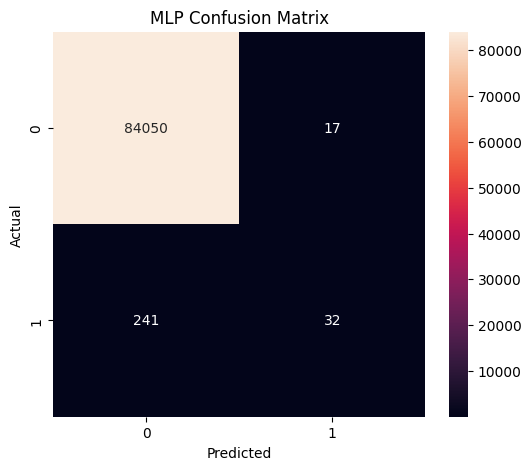


MODEL SAVED SUCCESSFULLY
Location : /content/drive/MyDrive/5/models


In [48]:
# =====================================================
# NAFLD - Multi Layer Perceptron (MLP)
# Google Colab + Google Drive
# Multiple CSV files
# =====================================================


import os
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.neural_network import MLPClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


import matplotlib.pyplot as plt
import seaborn as sns

import joblib



# =====================================================
# PATHS GOOGLE DRIVE
# =====================================================


PROJECT_PATH = "/content/drive/MyDrive/5"


DATA_FOLDER = PROJECT_PATH


MODEL_FOLDER = PROJECT_PATH + "/models"


RESULT_FOLDER = PROJECT_PATH + "/results"



# création automatique des dossiers

os.makedirs(
    MODEL_FOLDER,
    exist_ok=True
)


os.makedirs(
    RESULT_FOLDER,
    exist_ok=True
)



# =====================================================
# LOAD CSV FILES
# =====================================================


print("========== Loading CSV files ==========")


datasets = []


for file in os.listdir(DATA_FOLDER):

    if file.endswith(".csv"):


        path = os.path.join(
            DATA_FOLDER,
            file
        )


        print("Loading :", path)


        df = pd.read_csv(path)


        # garder le nom du fichier source

        df["source"] = file


        datasets.append(df)



if len(datasets) == 0:

    raise Exception(
        "No CSV files found"
    )



# fusion des 3 datasets

data = pd.concat(
    datasets,
    ignore_index=True
)



print("\nDataset loaded")

print(
    "Shape :",
    data.shape
)


print("\nColumns :")

print(
    data.columns.tolist()
)



# =====================================================
# DATA CLEANING
# =====================================================


print("\n========== Cleaning ==========")



# supprimer colonnes vides

data.dropna(
    axis=1,
    how="all",
    inplace=True
)



# remplir valeurs manquantes


for col in data.columns:


    if data[col].dtype == "object":

        data[col] = data[col].fillna(
            "Unknown"
        )

    else:

        data[col] = data[col].fillna(
            data[col].median()
        )



print("Cleaning completed")



# =====================================================
# TARGET
# =====================================================


# CHANGE THIS NAME
TARGET = "status"



if TARGET not in data.columns:


    print("\nColonnes disponibles :")

    print(data.columns.tolist())


    raise Exception(
        "Change TARGET with the real target column name"
    )



# Colonnes à supprimer
drop_columns = [
    TARGET,
    "Unnamed: 0",
    "source",
    "id",
    "case.id"
]


X = data.drop(
    columns=drop_columns,
    errors="ignore"
)


y = data[TARGET]





# =====================================================
# ENCODING
# =====================================================


print("\n========== Encoding ==========")



encoders = {}



for col in X.select_dtypes(
    include=["object"]
).columns:


    encoder = LabelEncoder()


    X[col] = encoder.fit_transform(
        X[col].astype(str)
    )


    encoders[col] = encoder




# encoder target

if y.dtype == "object":


    target_encoder = LabelEncoder()


    y = target_encoder.fit_transform(
        y.astype(str)
    )


    encoders["target"] = target_encoder



print("Encoding finished")



# =====================================================
# NORMALIZATION
# =====================================================


scaler = StandardScaler()


X = scaler.fit_transform(
    X
)


print("\nClasses de status :")
print(y.value_counts())
# =====================================================
# TRAIN TEST SPLIT
# =====================================================


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)



print("\nTraining data :", X_train.shape)

print("Testing data :", X_test.shape)



# =====================================================
# MLP MODEL
# =====================================================


print("\n========== Training MLP ==========")



model = MLPClassifier(

    hidden_layer_sizes=(128,64,32),

    activation="relu",

    solver="adam",

    max_iter=300,

    batch_size=32,

    learning_rate_init=0.001,

    random_state=42,

    verbose=True

)



model.fit(

    X_train,

    y_train

)



print("Training finished")



# =====================================================
# EVALUATION
# =====================================================


y_pred = model.predict(
    X_test
)



accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)


recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)


f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)



print("\n========== RESULTS ==========")


print(
    "Accuracy :",
    accuracy
)


print(
    "Precision :",
    precision
)


print(
    "Recall :",
    recall
)


print(
    "F1-score :",
    f1
)



print(
    classification_report(
        y_test,
        y_pred
    )
)



# =====================================================
# SAVE METRICS
# =====================================================


with open(
    RESULT_FOLDER + "/metrics.txt",
    "w"
) as f:


    f.write(
        classification_report(
            y_test,
            y_pred
        )
    )



# =====================================================
# CONFUSION MATRIX
# =====================================================


cm = confusion_matrix(
    y_test,
    y_pred
)



plt.figure(
    figsize=(6,5)
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.xlabel(
    "Predicted"
)


plt.ylabel(
    "Actual"
)


plt.title(
    "MLP Confusion Matrix"
)


plt.savefig(
    RESULT_FOLDER + "/confusion_matrix.png"
)


plt.show()



# =====================================================
# SAVE MODEL
# =====================================================


joblib.dump(

    model,

    MODEL_FOLDER + "/mlp_model.pkl"

)


joblib.dump(

    scaler,

    MODEL_FOLDER + "/scaler.pkl"

)


joblib.dump(

    encoders,

    MODEL_FOLDER + "/encoders.pkl"

)



print("\n================================")

print("MODEL SAVED SUCCESSFULLY")

print(
    "Location :",
    MODEL_FOLDER
)

print("================================")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [45]:
!pip install lightgbm